<a href="https://colab.research.google.com/github/padmasri2005/DataScience_Tasks/blob/main/Uber_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **UBER**

In [279]:
# importing necessary librraies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [280]:
# loading the data
df = pd.read_csv("https://github.com/Taj1920/Data_Analysis/raw/refs/heads/main/Uber_Analysis/UberDataset.csv")

In [281]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**Data cleaning**

In [282]:
# remove the last row
df.drop(df.index[1155],inplace=True)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site


In [283]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1155 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1155 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [284]:
df.isnull().sum()

,0
START_DATE,0
END_DATE,0
CATEGORY,0
START,0
STOP,0
MILES,0
PURPOSE,502


In [285]:
#  drop the duplicate rows
df.drop_duplicates(inplace=True)

In [286]:
#  resetting the index and dropping the old index col
df.reset_index(inplace = True)
df.drop('index',axis=1,inplace=True)
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


**EDA**

In [287]:
df['START_DATE'].unique()

array(['01-01-2016 21:11', '01-02-2016 01:25', '01-02-2016 20:25', ...,
       '12/31/2016 15:03', '12/31/2016 21:32', '12/31/2016 22:08'],
      dtype=object)

In [288]:
df['END_DATE'].unique()

array(['01-01-2016 21:17', '01-02-2016 01:37', '01-02-2016 20:38', ...,
       '12/31/2016 15:38', '12/31/2016 21:50', '12/31/2016 23:51'],
      dtype=object)

In [289]:
df['CATEGORY'].unique()

array(['Business', 'Personal'], dtype=object)

In [290]:
df['START'].unique()
df['START'] = df['START'].str.replace("?","a")
df['START'].unique()

array(['Fort Pierce', 'West Palm Beach', 'Cary', 'Jamaica', 'New York',
       'Elmhurst', 'Midtown', 'East Harlem', 'Flatiron District',
       'Midtown East', 'Hudson Square', 'Lower Manhattan',
       "Hell's Kitchen", 'Downtown', 'Gulfton', 'Houston', 'Eagan Park',
       'Morrisville', 'Durham', 'Farmington Woods', 'Whitebridge',
       'Lake Wellingborough', 'Fayetteville Street', 'Raleigh',
       'Hazelwood', 'Fairmont', 'Meredith Townes', 'Apex', 'Chapel Hill',
       'Northwoods', 'Edgehill Farms', 'Tanglewood', 'Preston',
       'Eastgate', 'East Elmhurst', 'Jackson Heights', 'Long Island City',
       'Katunayaka', 'Unknown Location', 'Colombo', 'Nugegoda',
       'Islamabad', 'Rawalpindi', 'Noorpur Shahan', 'Heritage Pines',
       'Westpark Place', 'Waverly Place', 'Wayne Ridge', 'Weston',
       'East Austin', 'West University', 'South Congress', 'The Drag',
       'Congress Ave District', 'Red River District', 'Georgian Acres',
       'North Austin', 'Coxville', 'Conven

In [291]:
df['STOP'].unique()
df['STOP'] = df['STOP'].str.replace("?","a")
df['STOP'].unique()

array(['Fort Pierce', 'West Palm Beach', 'Palm Beach', 'Cary',
       'Morrisville', 'New York', 'Queens', 'East Harlem', 'NoMad',
       'Midtown', 'Midtown East', 'Hudson Square', 'Lower Manhattan',
       "Hell's Kitchen", 'Queens County', 'Gulfton', 'Downtown',
       'Houston', 'Jamestown Court', 'Durham', 'Whitebridge',
       'Lake Wellingborough', 'Raleigh', 'Umstead', 'Hazelwood',
       'Westpark Place', 'Meredith Townes', 'Leesville Hollow', 'Apex',
       'Chapel Hill', 'Williamsburg Manor', 'Macgregor Downs',
       'Edgehill Farms', 'Northwoods', 'Tanglewood', 'Preston',
       'Walnut Terrace', 'Jackson Heights', 'East Elmhurst',
       'Midtown West', 'Long Island City', 'Jamaica', 'Unknown Location',
       'Colombo', 'Nugegoda', 'Katunayaka', 'Islamabad', 'Rawalpindi',
       'Noorpur Shahan', 'Heritage Pines', 'Waverly Place', 'Wayne Ridge',
       'Depot Historic District', 'Weston', 'West University',
       'South Congress', 'Arts District', 'Congress Ave District

In [292]:
df.MILES.unique()

array([  5.1,   5. ,   4.8,   4.7,  63.7,   4.3,   7.1,   0.8,   8.3,
        16.5,  10.8,   7.5,   6.2,   6.4,   1.6,   1.7,   1.9,   4. ,
         1.8,   2.4,   2. ,  15.1,  11.2,  11.8,  21.9,   3.9,   8. ,
        10.4,   7.2,   7.6,  17.1,  40.2,   1. ,   2.3,   1.4,   0.5,
        18.7,   3.4,   2.7,  12.9,  19. ,  14.7,  15.7,   4.6,   5.2,
        10.1,   5.8,   5.5,   5.7,  19.4,  23.3,   6. ,   9.7,   1.1,
         9. ,   7.7,  11.4,   3.2,   5.6,   6.1,   5.3,   3. ,   1.5,
        17.3,  13.5,   8.5,   2.6,  17. ,  18. ,   8.4,  11.5,   8.9,
         8.1,  13. ,  13.9,  43.7,  14.1,   4.5,   3.6,  21.4,  23.5,
        12.7,  10. ,  18.3,   7.3,   3.5,   4.2,  13.6,   2.5,  14.4,
        18.4,  23.1,  14.5,   8.8,  22.7,   2.2,  20. ,   3.1,   6.3,
        10.6,   9.9,   6.8,   2.1,   3.8,   6.6,  10.9,   4.9,   6.5,
         7.8,   2.8,  12.4,   5.9,   9.4,  11.9,  12.8,   1.2,  10.5,
        12.5, 136. ,  30.2,  15.5,  12.6,  13.2,   9.2,  12. ,  35.1,
        36.5,  57. ,

In [293]:
# handling null values in PURPOSE col
df['PURPOSE']=df['PURPOSE'].fillna('Unknown')

In [294]:
df.isnull().sum()

,0
START_DATE,0
END_DATE,0
CATEGORY,0
START,0
STOP,0
MILES,0
PURPOSE,0


**Feature Engineering using Date Columns**

In [295]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Unknown
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [296]:
# Replace '/' with '-' in START_DATE and END_DATE columns to Convert into datetime
df['START_DATE'] = df['START_DATE'].str.replace('/', '-')
df['END_DATE'] = df['END_DATE'].str.replace('/', '-')

In [297]:
# Convert to datetime
df['START_DATE'] = pd.to_datetime(df['START_DATE'])
df['END_DATE'] = pd.to_datetime(df['END_DATE'])

In [298]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1154 entries, 0 to 1153
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  1154 non-null   datetime64[ns]
 1   END_DATE    1154 non-null   datetime64[ns]
 2   CATEGORY    1154 non-null   object        
 3   START       1154 non-null   object        
 4   STOP        1154 non-null   object        
 5   MILES       1154 non-null   float64       
 6   PURPOSE     1154 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 63.2+ KB


In [299]:

#  Splitting the START_DATE and END_DATE to date and time column
df['DATE']=pd.DatetimeIndex(df['START_DATE']).date
df['TIME']=pd.DatetimeIndex(df['START_DATE']).hour


In [300]:

# Calculate ride minutes
df['Ride_Minutes'] = (df['END_DATE'] - df['START_DATE']).dt.total_seconds() // 60

In [301]:
# Categorize rides into Morning, Afternoon, Evening, and Night based on ride time
out=[]
for i in df['TIME']:
  if 0<=i<=10:
    out.append('Morning')
  elif 11<=i<=15:
    out.append('Afternoon')
  elif 16<=i<=19:
    out.append('Evening')
  elif 20<=i<=24:
    out.append('Night')
df['DAY-NIGHT']=out
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,Ride_Minutes,DAY-NIGHT
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,6.0,Night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,2016-01-02,1,12.0,Morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,13.0,Night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,14.0,Evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,67.0,Afternoon
...,...,...,...,...,...,...,...,...,...,...,...
1149,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Karachi,Karachi,0.7,Meeting,2016-12-31,1,7.0,Morning
1150,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Karachi,Unknown Location,3.9,Temporary Site,2016-12-31,13,18.0,Afternoon
1151,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,2016-12-31,15,35.0,Afternoon
1152,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,2016-12-31,21,18.0,Night


In [302]:
#creating month column
df['MONTH']=[i.month for i in df['START_DATE']]
df['MONTH']=df['MONTH'].map({1:'JAN',  2:'FEB',  3:'MAR',  4:'APR',  5:'MAY',  6:'JUN',  7:'JUL',  8:'AUG',  9:'SEP', 10:'OCT', 11:'NOV', 12:'DEC'})
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,Ride_Minutes,DAY-NIGHT,MONTH
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,6.0,Night,JAN
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,2016-01-02,1,12.0,Morning,JAN
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,13.0,Night,JAN
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,14.0,Evening,JAN
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,67.0,Afternoon,JAN
...,...,...,...,...,...,...,...,...,...,...,...,...
1149,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Karachi,Karachi,0.7,Meeting,2016-12-31,1,7.0,Morning,DEC
1150,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Karachi,Unknown Location,3.9,Temporary Site,2016-12-31,13,18.0,Afternoon,DEC
1151,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,2016-12-31,15,35.0,Afternoon,DEC
1152,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,2016-12-31,21,18.0,Night,DEC


In [303]:

#creating day column
df['DAY']=df['START_DATE'].dt.weekday
df['DAY']=df['DAY'].map({0:'MON',1:'TUE',2:'WED',3:'THU',4:'FRI',5:'SAT',6:'SUN'})
df


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,DATE,TIME,Ride_Minutes,DAY-NIGHT,MONTH,DAY
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,6.0,Night,JAN,FRI
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,2016-01-02,1,12.0,Morning,JAN,SAT
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,13.0,Night,JAN,SAT
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,14.0,Evening,JAN,TUE
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,67.0,Afternoon,JAN,WED
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1149,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Karachi,Karachi,0.7,Meeting,2016-12-31,1,7.0,Morning,DEC,SAT
1150,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Karachi,Unknown Location,3.9,Temporary Site,2016-12-31,13,18.0,Afternoon,DEC,SAT
1151,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,2016-12-31,15,35.0,Afternoon,DEC,SAT
1152,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,2016-12-31,21,18.0,Night,DEC,SAT


**Data Visualization**

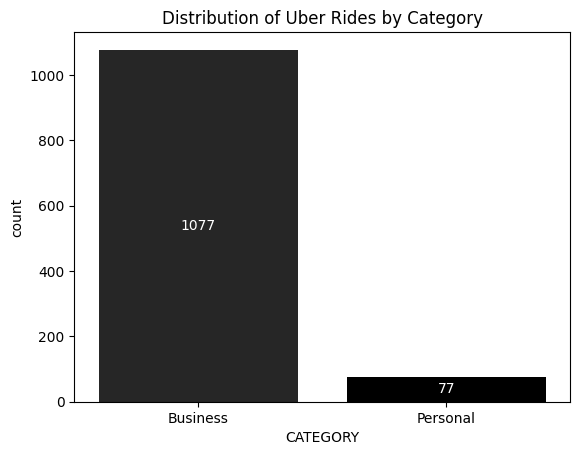

In [304]:
# Count of rides by category
a = sns.countplot(x='CATEGORY', data=df, hue='CATEGORY', palette='dark:black')

for container in a.containers:
    a.bar_label(container, label_type='center', color='white')

plt.title("Distribution of Uber Rides by Category")

plt.show()


Count of Business category is more

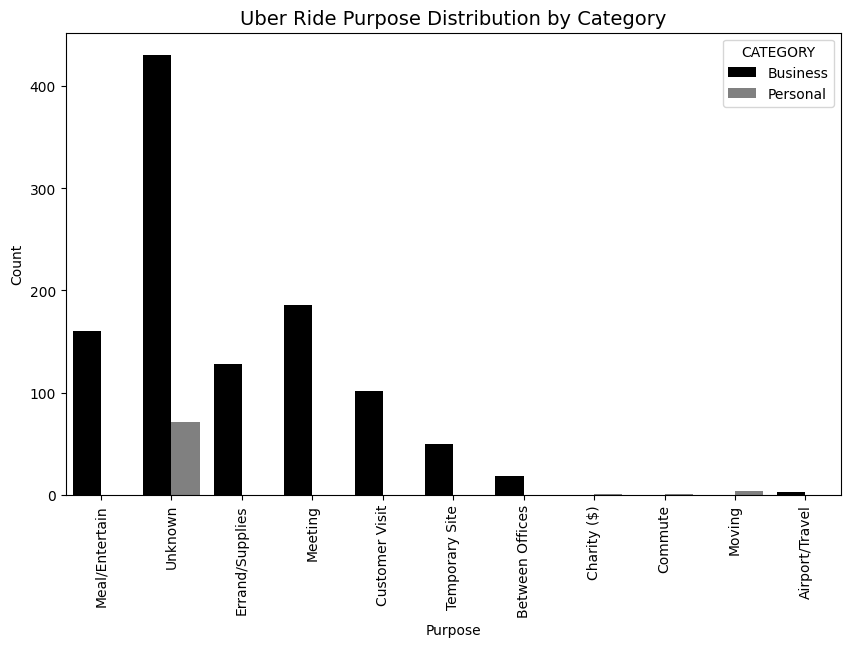

In [305]:

uber_palette = sns.color_palette(["black", "gray"])

plt.figure(figsize=(10,6))

sns.countplot(x='PURPOSE',data=df,hue='CATEGORY',palette={'Business':'black', 'Personal':'gray'})

plt.xticks(rotation=90)

plt.title("Uber Ride Purpose Distribution by Category",fontsize=14,color='black')

plt.xlabel("Purpose", color='black')
plt.ylabel("Count", color='black')

plt.show()

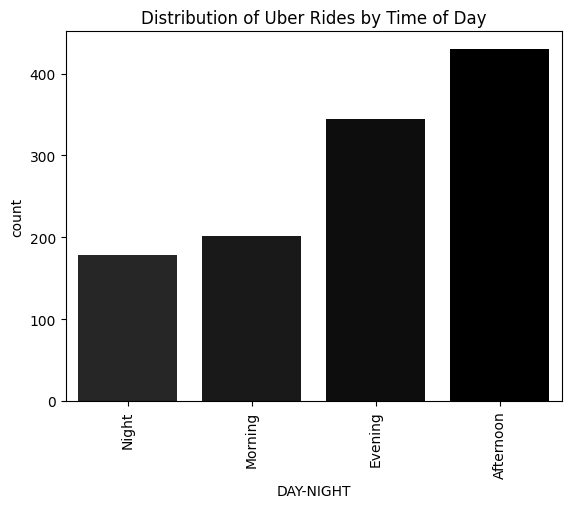

In [306]:
# Count of rides by time of day
sns.countplot(x="DAY-NIGHT", data=df, hue="DAY-NIGHT", palette="dark:black")

plt.xticks(rotation=90)
plt.title("Distribution of Uber Rides by Time of Day")

plt.show()

Most Uber rides occur in the **afternoon**, followed by **evening**, while **night has the least number of rides**.


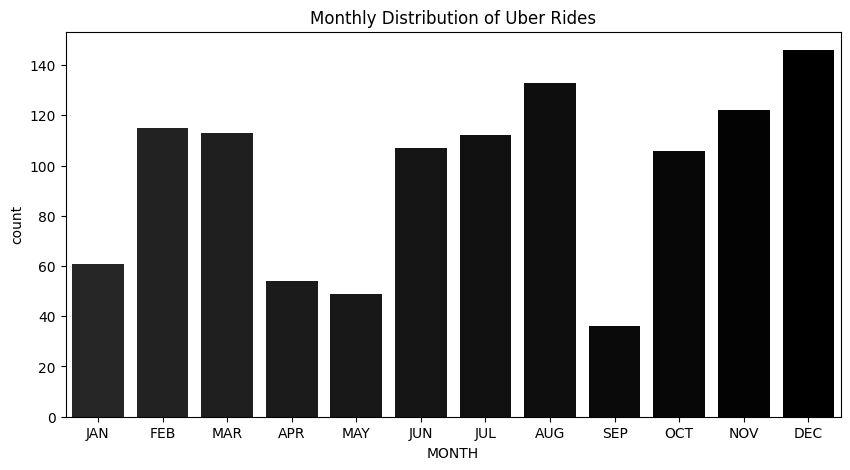

In [307]:
# Count of rides by month
plt.figure(figsize=(10,5))
sns.countplot(x='MONTH', data=df, hue='MONTH', palette='dark:black')

plt.title("Monthly Distribution of Uber Rides")

plt.show()

Uber ride frequency is **highest in December and August**, while **September and May have the lowest number of rides**.


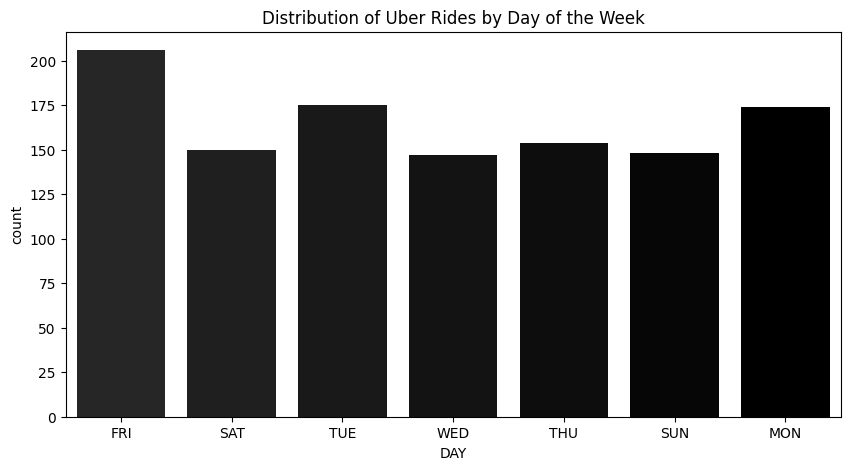

In [308]:
# Count of rides by day of the week
plt.figure(figsize=(10,5))
sns.countplot(x='DAY', data=df, hue='DAY', palette='dark:black')

plt.title("Distribution of Uber Rides by Day of the Week")

plt.show()

Uber rides are **highest on Friday**, indicating increased travel demand at the end of the workweek, while **Saturday and midweek days show comparatively lower ride counts**.


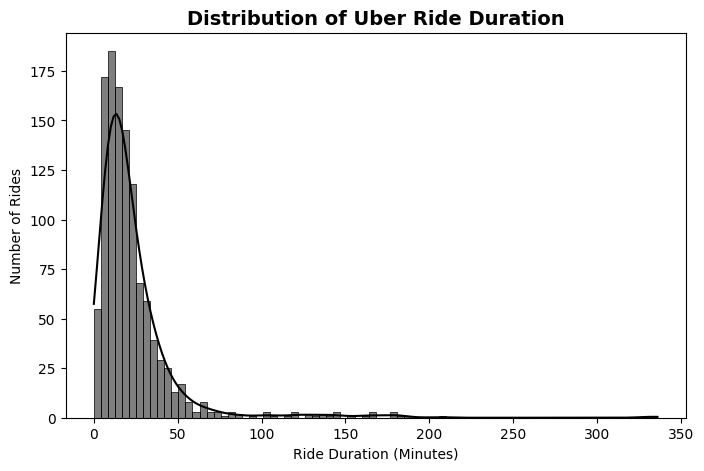

In [309]:
plt.figure(figsize=(8,5))

sns.histplot(df['Ride_Minutes'], bins=80, color='black',kde = True)

plt.title("Distribution of Uber Ride Duration", fontsize=14, weight='bold')
plt.xlabel("Ride Duration (Minutes)")
plt.ylabel("Number of Rides")

plt.show()

Most Uber rides have short durations (around **5–30 minutes**), with only a few long rides extending beyond 100 minutes.

### **Conclusion**

* Most Uber rides are **business-related rather than personal**.
* Ride demand is **highest during the afternoon and evening**.
* **Short-duration rides (5–30 minutes)** make up the majority of trips.
* Ride frequency varies by month, with **December having the highest number of rides**.

### **Recommendations**

* Increase **driver availability during peak hours (afternoon and evening)**.
* Focus on **optimizing short-distance ride services**, since most trips are brief.
* Plan **better driver allocation during high-demand months** to reduce wait times.
